# Hierarchical Agent란?

**Hierarchical Agent**는 계층적 구조로 작업을 **분류하고 위임**하는 Multi-Agent 패턴입니다.



### 핵심 특징

1. **단순 분류와 실행** (Classify & Execute)
   - 상위 에이전트가 입력을 분석하여 적절한 하위 에이전트로 라우팅
   - 한 번의 분류로 작업 완료 (1회성 실행)
   
2. **명확한 역할 분담** (Clear Role Division)
   - 각 하위 에이전트는 특정 도메인에 특화
   - 서로 독립적으로 작동
   
3. **조건부 라우팅** (Conditional Routing)
   - 입력 내용에 따라 다른 경로로 분기
   - if-else 로직과 유사한 흐름

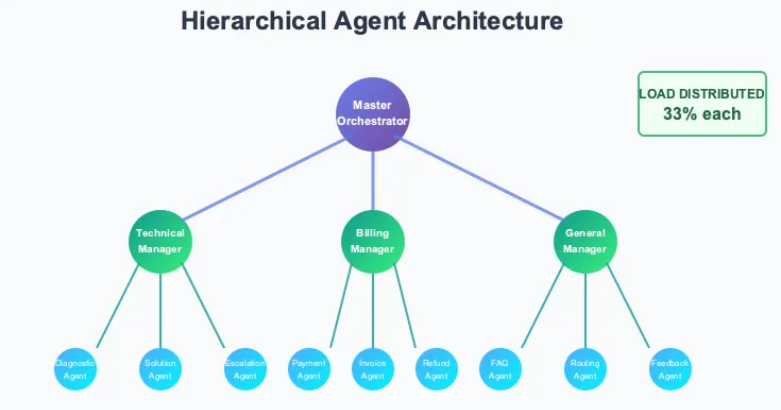

# Multi Agents - 고객 지원 챗봇
LangGraph를 활용하여 여러 에이전트가 협력하는 고객 지원 챗봇을 구현합니다.


### 작동 방식

```
사용자 입력
    ↓
분류 에이전트 (Classifier)
    ↓
조건부 라우팅
    ├─→ 에이전트 A (특정 업무)
    ├─→ 에이전트 B (특정 업무)
    └─→ 에이전트 C (특정 업무)
    ↓
최종 응답
```


### 적합한 사용 사례

- 고객 지원 시스템 (기술/결제/일반 상담)
- 문서 분류 및 처리
- 이메일 자동 라우팅
- 간단한 의사결정 트리


## 구성
1. **분류 에이전트**: 고객 문의 유형을 판단 (기술/결제/일반)
2. **기술 지원 에이전트**: 기술 문제 해결
3. **결제 지원 에이전트**: 결제 관련 처리
4. **일반 상담 에이전트**: 일반 문의 응답


### 이 예제가 Hierarchical Agent인 이유

**고객 지원 챗봇**은 Hierarchical Agent의 전형적인 사례입니다:

1. **분류 단계**: 고객 문의를 분석하여 유형 판단 (기술/결제/일반)
2. **라우팅**: 문의 유형에 따라 전문 에이전트로 분기
3. **독립 실행**: 각 지원 에이전트가 자신의 영역만 처리
4. **1회성 완료**: 한 번의 라우팅으로 작업 종료

**vs. Supervisor Agent**: Supervisor는 여러 에이전트를 순차적으로 조율하지만, Hierarchical은 단순히 하나의 에이전트를 선택하여 실행합니다.

## 환경 설정
- [LangSmith API Key](https://smith.langchain.com/)

In [1]:
from dotenv import load_dotenv

# 환경변수 로드
load_dotenv()

True

## 1단계: LLM 모델 초기화 


- 모델 다운로드 하기 
    ```shell
    ollama pull gemma3:4b
    ```
- 모델 다운로드 확인 
    ```shell
    ollama list
    ```

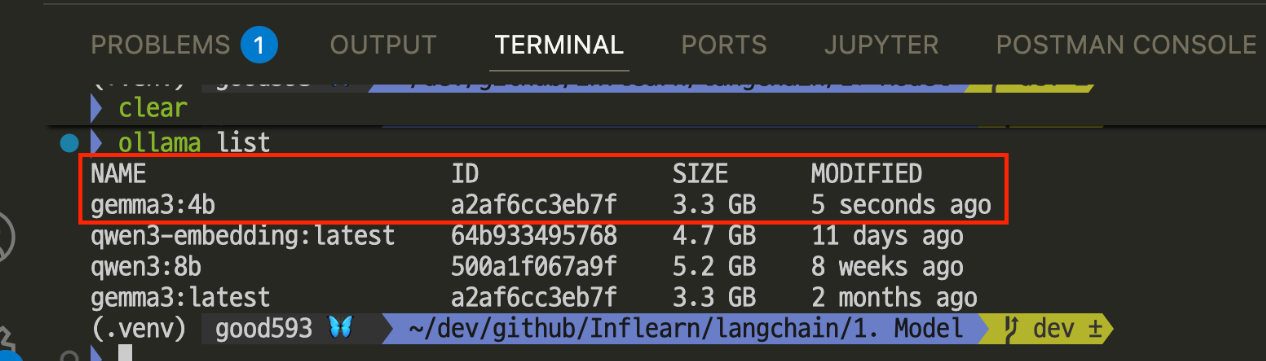

> Ollama 정확한 답변용 파라미터 

| 파라미터          | 값            | 설명                    |
| ------------- | ------------ | --------------------- |
| `temperature` | `0.0 ~ 0.2`  | 무작위성 최소화, 항상 같은 결과 유도 |
| `top_p`       | `1.0`        | 전체 확률 분포 사용 (안정성 중심)  |
| `num_predict` | `256`        | 간결한 답변 생성             |
| `model`       | `"llama3.1"` | 정확도 중심 모델             |
| `keep_alive`  | `"5m"`       | 짧게 유지 (리소스 절약)        |


In [2]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.1,
    top_p=1.0,
    keep_alive="5m"
)

## 2단계: 상태 정의 (State Management)

그래프에서 사용할 상태 구조를 정의합니다. 상태는 모든 노드 간에 공유되며, 각 에이전트가 정보를 추가하거나 수정할 수 있습니다.


In [3]:
from typing import TypedDict, NotRequired, Literal

class SupportState(TypedDict):
    """
    고객 지원 챗봇의 상태를 표현하는 타입.

    Attributes:
        question (str): 고객이 입력한 원본 문의 내용.
        category (Literal["technical", "billing", "general"] | None):
            분류 에이전트가 판별한 문의 유형.
            초기 상태에서는 None일 수 있음.
        response (NotRequired[str]):
            최종 지원 에이전트가 생성한 응답 메시지.
            아직 생성되지 않은 경우 omitted(없음)이 될 수 있음.
    """

    question: str
    category: Literal["technical", "billing", "general"] | None
    response: NotRequired[str]
    


## 3단계: 에이전트 노드 정의

각 에이전트의 역할과 기능을 정의합니다.


### 분류 에이전트 (Classifier Agent)

고객의 문의 내용을 분석하여 적절한 지원 유형으로 분류합니다.


In [4]:
from langchain_core.messages import HumanMessage, SystemMessage

def classifier_agent(state: SupportState) -> SupportState:
    """
    고객 문의를 분석하여 적절한 카테고리로 분류하는 에이전트
    """
    question = state["question"]
    
    # LLM을 사용하여 문의 유형 분류
    messages = [
        SystemMessage(content="""
            당신은 고객 문의를 분류하는 전문가입니다.
            고객의 문의를 다음 세 가지 카테고리 중 하나로 분류하세요:

            1. technical - 기술적 문제, 오류, 버그, 기능 작동 문제 등
            2. billing - 결제, 환불, 요금제, 구독 관련 문제
            3. general - 일반 문의, 제품 정보, 사용 방법 등

            반드시 'technical', 'billing', 'general' 중 하나의 단어만 응답하세요."""),
        HumanMessage(content=f"다음 문의를 분류하세요: {question}")
    ]
    
    response = llm.invoke(messages)
    category = response.content.strip().lower()
    
    print(f"[분류 에이전트] 문의 유형: {category}")
    
    return {
        "question": question,
        "category": category
    }


In [5]:
# 테스트
test_state = {"question": "로그인이 안됩니다"}
result = classifier_agent(test_state)
print(f"분류 결과: {result['category']}")

[분류 에이전트] 문의 유형: technical
분류 결과: technical


### 기술 지원 에이전트

기술적인 문제를 해결하는 전문 에이전트입니다.


In [6]:
def technical_support_agent(state: SupportState) -> SupportState:
    """
    기술적 문제를 해결하는 에이전트
    """
    question = state["question"]
    
    messages = [
        SystemMessage(content="""
            당신은 기술 지원 전문가입니다.
            고객의 기술적 문제를 친절하고 명확하게 해결해주세요.
            단계별 해결 방법을 제시하고, 가능한 원인을 설명하세요."""),
        HumanMessage(content=question)
    ]
    
    response = llm.invoke(messages)
    answer = response.content
    
    print(f"[기술 지원 에이전트] 응답 생성 완료")
    
    return {
        **state,
        "response": answer
    }


In [7]:
test_state = {"question": "앱이 자꾸 강제 종료됩니다. 어떻게 해야 하나요?"}
result = technical_support_agent(test_state)
print(f"기술적 문제 답변: {result['response']}")

[기술 지원 에이전트] 응답 생성 완료
기술적 문제 답변: 안녕하세요! 앱이 계속해서 강제 종료되는 문제로 불편을 겪고 계시다니 정말 안타깝습니다. 하지만 걱정 마세요. 제가 단계별로 해결 방법을 안내해 드리겠습니다. 

**1단계: 문제 재현 확인 및 정보 수집**

*   **어떤 앱에서 발생하나요?** 특정 앱에서만 발생하는지, 아니면 여러 앱에서 모두 발생하는지 확인합니다.
*   **언제 강제 종료되나요?** 앱을 실행할 때, 특정 기능을 사용할 때, 또는 아무 때나 발생하는지 확인합니다.
*   **강제 종료되기 전에 어떤 화면이 보이나요?** 오류 메시지가 나타나는지, 또는 다른 이상한 현상이 발생하는지 확인합니다.
*   **휴대폰 모델명과 운영체제 버전을 알려주세요.** (예: 삼성 갤럭시 S23, 안드로이드 13)

이 정보들을 알려주시면 문제 해결에 더욱 도움이 될 것입니다.

**2단계: 기본적인 해결 방법**

1.  **휴대폰 재부팅:** 가장 간단하지만 효과적인 방법입니다. 일시적인 오류를 해결할 수 있습니다.
2.  **앱 캐시 및 데이터 삭제:** 앱의 캐시 데이터가 손상되어 문제가 발생할 수 있습니다.
    *   **안드로이드:** 설정 > 앱 > 해당 앱 선택 > 저장공간 > 캐시 삭제
    *   **iOS:** 설정 > 앱 > 해당 앱 선택 > 저장공간 > 저장공간 지우기
3.  **앱 업데이트 확인:** 앱의 최신 버전으로 업데이트되어 있는지 확인합니다. 버그 수정 및 성능 개선이 포함되어 있을 수 있습니다.
4.  **운영체제 업데이트 확인:** 휴대폰의 운영체제(안드로이드 또는 iOS)가 최신 버전인지 확인합니다.

**3단계: 심층적인 해결 방법 (위 방법으로 해결되지 않을 경우)**

1.  **앱 재설치:** 앱을 삭제하고 다시 설치합니다. 설치 과정에서 손상된 파일이 제거될 수 있습니다.
2.  **백그라운드 앱 제한:** 일부 앱은 백그라운드에서 과도하게 실행되어 시스템 자원을 소모하고 충돌을 일으킬 수

### 결제 지원 에이전트

결제 및 청구 관련 문제를 처리하는 에이전트입니다.


In [8]:
def billing_support_agent(state: SupportState) -> SupportState:
    """
    결제 및 청구 관련 문제를 처리하는 에이전트
    """
    question = state["question"]
    
    messages = [
        SystemMessage(content="""
            당신은 결제 및 청구 관련 전문 상담원입니다.
            고객의 결제, 환불, 요금제 관련 문의에 정확하고 친절하게 답변하세요.
            필요한 경우 정책과 절차를 안내하세요."""),
        HumanMessage(content=question)
    ]
    
    response = llm.invoke(messages)
    answer = response.content
    
    print(f"[결제 지원 에이전트] 응답 생성 완료")
    
    return {
        **state,
        "response": answer
    }


In [9]:
test_state = {"question": "구독을 취소하고 환불받고 싶습니다."}
result = billing_support_agent(test_state)
print(f"결제 및 청구 관련 문제 답변: {result['response']}")

[결제 지원 에이전트] 응답 생성 완료
결제 및 청구 관련 문제 답변: 안녕하세요. 고객님, 불편을 드려 죄송합니다. 구독 취소 및 환불 문의에 대해 자세히 안내해 드리겠습니다. 

먼저, 어떤 서비스에 대한 구독 취소 및 환불를 원하시는지 알려주시면 더욱 정확한 안내가 가능합니다. (예: OTT 서비스, 멤버십 서비스, 통신 요금 등)

**일반적인 구독 취소 및 환불 절차는 다음과 같습니다.**

1.  **구독 취소:**
    *   **온라인:** 해당 서비스 웹사이트 또는 앱에서 계정 설정 메뉴를 통해 구독을 취소할 수 있습니다.
    *   **전화:** 고객센터로 전화하여 담당자에게 구독 취소를 요청할 수 있습니다.
    *   **이메일:** 고객센터 이메일 주소로 구독 취소 요청을 보내실 수 있습니다.

2.  **환불 정책 확인:**
    *   각 서비스마다 환불 정책이 다릅니다. 일반적으로 다음과 같은 사항을 확인해야 합니다.
        *   **환불 가능 기간:** 구독 취소 후 일정 기간 내에 환불을 요청해야 합니다. (예: 7일, 14일, 30일 등)
        *   **환불 조건:** 환불 가능 여부는 구독 기간, 사용량, 서비스 종류 등에 따라 달라질 수 있습니다.
        *   **환불 금액:** 환불 가능한 금액은 전체 구독료에서 사용량에 따라 차감된 금액입니다.

3.  **환불 신청:**
    *   구독 취소 후, 환불 신청을 위한 절차를 안내받습니다. (예: 환불 신청서 작성, 환불 계좌 정보 입력 등)
    *   환불 신청 후, 해당 서비스의 환불 정책에 따라 환불 처리 기간이 소요됩니다.

**고객님의 상황에 맞는 정확한 정보를 제공하기 위해 몇 가지 추가 질문을 드립니다.**

*   어떤 서비스에 대한 구독을 취소하고 환불를 원하시나요?
*   구독 취소를 요청하게 된 구체적인 이유가 있으신가요? (예: 서비스 이용 불량, 경제적인 이유 등)
*   구독 시작일은 언제인가요?
*  

### 일반 상담 에이전트

일반적인 문의사항을 처리하는 에이전트입니다.


In [10]:
def general_support_agent(state: SupportState) -> SupportState:
    """
    일반적인 문의사항을 처리하는 에이전트
    """
    question = state["question"]
    
    messages = [
        SystemMessage(content="""
            당신은 친절한 고객 상담원입니다.
            고객의 일반적인 문의에 친절하고 유용한 정보를 제공하세요.
            제품이나 서비스에 대한 설명을 명확하게 전달하세요."""),
        HumanMessage(content=question)
    ]
    
    response = llm.invoke(messages)
    answer = response.content
    
    print(f"[일반 상담 에이전트] 응답 생성 완료")
    
    return {
        **state,
        "response": answer
    }


In [11]:
test_state = {"question": "프리미엄 플랜에는 어떤 기능들이 포함되나요?"}
result = general_support_agent(test_state)
print(f"일반적인 문의사항 답변: {result['response']}")

[일반 상담 에이전트] 응답 생성 완료
일반적인 문의사항 답변: 안녕하세요! 프리미엄 플랜에 대해 문의주셔서 감사합니다. 프리미엄 플랜은 저희 서비스를 최대한 활용하실 수 있도록 설계된 최고의 옵션입니다. 프리미엄 플랜에는 다음과 같은 혜택이 포함되어 있습니다.

**1. 핵심 기능:**

*   **무제한 사용:** 모든 기능(기본 기능 포함)을 무제한으로 이용하실 수 있습니다.
*   **고화질 스트리밍:** 4K 해상도까지 지원하여 더욱 선명하고 생생한 영상 시청 경험을 제공합니다.
*   **빠른 속도:** 네트워크 속도 제한 없이 최적의 스트리밍 속도를 제공합니다.
*   **우선 지원:** 고객센터 문의 시 일반 플랜 사용자보다 빠른 응답 속도와 우선적인 지원을 받으실 수 있습니다.

**2. 추가 혜택:**

*   **개인 맞춤형 추천:** 사용자의 취향을 분석하여 더욱 정확하고 만족스러운 콘텐츠를 추천해 드립니다.
*   **독점 콘텐츠:** 프리미엄 회원 전용으로 제공되는 특별한 영화, 드라마, 다큐멘터리 등 독점 콘텐츠를 즐기실 수 있습니다. (정기적으로 업데이트됩니다.)
*   **오프라인 다운로드:** 좋아하는 콘텐츠를 다운로드하여 인터넷 연결 없이도 시청할 수 있습니다. (다운로드 용량 제한 없음)
*   **고화질 자막:** 더욱 선명하고 깨끗한 고화질 자막을 지원합니다.
*   **가족 공유:** 최대 5명까지 가족 구성원과 함께 프리미엄 플랜을 공유할 수 있습니다. (각 사용자별로 별도 계정 생성)

**3. 가격:**

*   월간: 19,800원
*   연간: 198,000원 (월 16,500원)

**더 궁금하신 점이 있으신가요?**

*   특정 콘텐츠에 대한 질문
*   기술적인 문제 해결
*   가격 정책 관련 질문

어떤 질문이든 편하게 문의해주세요. 고객님의 만족을 위해 최선을 다하겠습니다. 😊


## 4단계: 조건부 라우팅 (Conditional Routing)

분류 결과에 따라 적절한 에이전트로 라우팅하는 함수를 정의합니다.


In [12]:
from typing import Literal

def route_question(state: SupportState) -> Literal["technical", "billing", "general"]:
    """
    분류된 카테고리에 따라 적절한 에이전트로 라우팅하는 함수
    """
    category = state["category"]
    
    print(f"[라우터] '{category}' 카테고리로 라우팅")
    
    # 카테고리에 따라 다음 노드 결정
    if category == "technical":
        return "technical"
    elif category == "billing":
        return "billing"
    else:
        return "general"


## 5단계: 그래프 구성

LangGraph를 사용하여 전체 워크플로우를 구성합니다.

In [13]:
from langgraph.graph import StateGraph, END, START

# StateGraph 생성
workflow = StateGraph(SupportState)

# 노드 추가
workflow.add_node("classifier", classifier_agent)
workflow.add_node("technical", technical_support_agent)
workflow.add_node("billing", billing_support_agent)
workflow.add_node("general", general_support_agent)

# 시작점 설정
workflow.add_edge(START, "classifier")

# 조건부 엣지 추가 (분류 에이전트 -> 라우팅)
workflow.add_conditional_edges(
    "classifier",  # 출발 노드
    route_question,  # 라우팅 함수
    {
        "technical": "technical",  # 기술 지원으로
        "billing": "billing",      # 결제 지원으로
        "general": "general"       # 일반 상담으로
    }
)

# 각 전문 에이전트에서 END로 연결
workflow.add_edge("technical", END)
workflow.add_edge("billing", END)
workflow.add_edge("general", END)

# 그래프 컴파일
app = workflow.compile()


## 6단계: 그래프 시각화 (선택사항)

그래프의 구조를 시각적으로 확인할 수 있습니다.


```
시작
  |
  v
분류 에이전트
  |
  v
조건부 라우팅
  |
  +-- technical --> 기술 지원 에이전트 --> 종료
  |
  +-- billing --> 결제 지원 에이전트 --> 종료
  |
  +-- general --> 일반 상담 에이전트 --> 종료
```


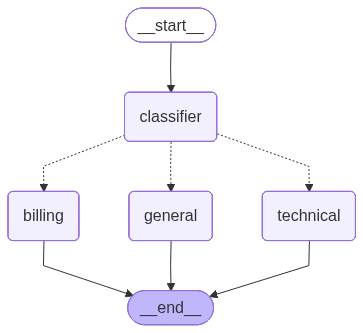

In [14]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

## 7단계: 테스트 예제

다양한 문의 유형으로 챗봇을 테스트해봅니다.


### 테스트 케이스 1: 기술 지원 문의


In [15]:
question1 = "앱이 자꾸 강제 종료됩니다. 어떻게 해야 하나요?"

# 초기 상태 생성
initial_state = {
    "question": question1
}

# 그래프 실행
result = app.invoke(initial_state)

print(f"\n질문: {result['question']}")
print(f"분류: {result['category']}")
print(f"\n응답:\n{result['response']}")
print("=" * 60)


[분류 에이전트] 문의 유형: technical
[라우터] 'technical' 카테고리로 라우팅
[기술 지원 에이전트] 응답 생성 완료

질문: 앱이 자꾸 강제 종료됩니다. 어떻게 해야 하나요?
분류: technical

응답:
안녕하세요! 앱이 계속해서 강제 종료되는 문제로 불편을 겪고 계시는군요. 정말 답답하시겠네요. 제가 최대한 자세하게 해결 방법을 안내해 드리겠습니다. 

**1단계: 문제 재현 확인 및 정보 수집**

*   **어떤 앱에서 발생하나요?** 특정 앱에서만 발생하는지, 아니면 여러 앱에서 모두 발생하는지 확인해주세요.
*   **언제 강제 종료되나요?** 앱을 실행할 때, 특정 기능을 사용할 때, 또는 아무 때나 갑자기 강제 종료되는지 확인해주세요.
*   **강제 종료되기 전에 어떤 화면이 보이나요?** 오류 메시지가 나타나거나, 특정 동작을 수행하고 있을 때 발생하는지 확인해주세요.
*   **휴대폰 모델명과 운영체제 버전을 알려주세요.** (예: 삼성 갤럭시 S23, 안드로이드 13)

이 정보들을 알려주시면 문제 해결에 더욱 도움이 될 수 있습니다.

**2단계: 기본적인 해결 방법**

1.  **휴대폰 재부팅:** 가장 간단하지만 효과적인 방법입니다. 일시적인 오류를 해결할 수 있습니다.
2.  **앱 캐시 및 데이터 삭제:** 앱 자체의 문제일 수 있으므로, 앱의 캐시와 데이터를 삭제해 보세요.
    *   **안드로이드:** 설정 > 앱 > 해당 앱 선택 > 저장공간 > 캐시 삭제 또는 데이터 삭제 (데이터 삭제 시 앱 설정 초기화될 수 있습니다.)
    *   **iOS:** 설정 > 앱 > 해당 앱 선택 > 저장공간 > 앱 데이터 삭제
3.  **앱 업데이트 확인:** 앱의 최신 버전이 있는지 확인하고, 업데이트가 있다면 진행해주세요. 버그 수정 및 성능 개선이 포함되어 있을 수 있습니다.
4.  **운영체제 업데이트 확인:** 휴대폰의 운영체제(안드로이드 또는 iOS)가 최신 버전인지 확인하고, 업데이트가 있다면

### 테스트 케이스 2: 결제 지원 문의


In [16]:
question2 = "구독을 취소하고 환불받고 싶습니다."

initial_state = {
    "question": question2
}

result = app.invoke(initial_state)

print(f"\n질문: {result['question']}")
print(f"분류: {result['category']}")
print(f"\n응답:\n{result['response']}")
print("=" * 60)


[분류 에이전트] 문의 유형: billing
[라우터] 'billing' 카테고리로 라우팅
[결제 지원 에이전트] 응답 생성 완료

질문: 구독을 취소하고 환불받고 싶습니다.
분류: billing

응답:
안녕하세요. 고객님, 불편을 드려 죄송합니다. 구독 취소 및 환불 문의 주셔서 감사합니다. 

먼저, 어떤 서비스에 대한 구독 취소 및 환불를 원하시는지 여쭤봐도 될까요? 서비스명과 함께 구독 계정 정보(예: 이메일 주소, 가입 날짜 등)를 알려주시면 더욱 정확하고 빠르게 처리해 드릴 수 있습니다.

**일반적인 구독 취소 및 환불 절차는 다음과 같습니다.**

1.  **취소 신청:**
    *   **온라인 취소:** 서비스 웹사이트 또는 앱에서 계정 설정 메뉴를 통해 구독을 취소할 수 있습니다.
    *   **고객센터 문의:** 전화 또는 이메일을 통해 고객센터에 문의하여 취소 신청을 할 수 있습니다.
2.  **환불 정책 확인:**
    *   환불 가능 여부는 서비스의 환불 정책에 따라 달라집니다. 일반적으로 다음과 같은 사항을 확인합니다.
        *   **환불 가능 기간:** 구독 시작 후 일정 기간 내에만 환불 신청이 가능한 경우가 많습니다.
        *   **환불 조건:** 서비스 이용 기간, 미사용 기간, 요금제 등에 따라 환불 금액이 달라질 수 있습니다.
        *   **환불 수수료:** 환불 시 수수료가 발생할 수 있습니다.
3.  **환불 신청 및 처리:**
    *   환불 신청서를 작성하고 필요한 서류를 제출합니다.
    *   고객센터에서 환불 신청을 접수하고, 환불 정책에 따라 환불 절차를 진행합니다.
    *   환불 완료 시 환불 금액 및 완료 시점에 안내해 드립니다.

**참고:**

*   **환불 정책:** [서비스명]의 환불 정책은 [환불 정책 링크]에서 확인하실 수 있습니다.
*   **환불 처리 기간:** 환불 신청 접수 후 환불 완료까지 최대 [일수] 정도 소요될 수 있습니다.

### 테스트 케이스 3: 일반 상담 문의


In [17]:
question3 = "프리미엄 플랜에는 어떤 기능들이 포함되나요?"

initial_state = {
    "question": question3
}

result = app.invoke(initial_state)

print(f"\n질문: {result['question']}")
print(f"분류: {result['category']}")
print(f"\n응답:\n{result['response']}")
print("=" * 60)


[분류 에이전트] 문의 유형: general
[라우터] 'general' 카테고리로 라우팅
[일반 상담 에이전트] 응답 생성 완료

질문: 프리미엄 플랜에는 어떤 기능들이 포함되나요?
분류: general

응답:
안녕하세요! 프리미엄 플랜에 대해 문의주셔서 감사합니다. 프리미엄 플랜은 저희 서비스를 최대한 활용하실 수 있도록 설계된 최고의 옵션입니다. 프리미엄 플랜에는 다음과 같은 혜택이 포함되어 있습니다.

**1. 핵심 기능:**

*   **무제한 사용:** 모든 기능(기본 기능 포함)을 무제한으로 이용하실 수 있습니다.
*   **고화질 스트리밍:** 4K 해상도까지 지원하여 더욱 선명하고 생생한 영상 시청 경험을 제공합니다.
*   **빠른 속도:** 네트워크 속도 제한 없이 원활한 스트리밍 및 다운로드 경험을 제공합니다.
*   **우선 지원:** 일반 플랜 사용자보다 빠른 응답 속도의 고객 지원을 받으실 수 있습니다.

**2. 추가 혜택:**

*   **개인 맞춤형 추천:** 저희 서비스 이용 기록을 기반으로 더욱 정확하고 개인화된 콘텐츠 추천을 받으실 수 있습니다.
*   **독점 콘텐츠:** 프리미엄 회원 전용으로 제공되는 특별한 콘텐츠를 즐기실 수 있습니다. (콘텐츠 종류는 변경될 수 있습니다.)
*   **오프라인 다운로드:** 스트리밍이 어려운 환경에서도 콘텐츠를 다운로드하여 오프라인에서 즐길 수 있습니다.
*   **고객 지원 우선 처리:** 긴급한 문제 발생 시 일반 플랜 사용자보다 빠른 지원을 받으실 수 있습니다.

**3. 가격:**

*   월간: 9,900원
*   연간: 99,000원 (월 8,250원)

**더 궁금하신 점이 있으신가요?**

*   프리미엄 플랜과 일반 플랜의 주요 차이점을 더 자세히 알고 싶으시다면, 비교표를 보내드릴 수 있습니다.
*   특정 콘텐츠를 시청하는 데 프리미엄 플랜이 필요한지 궁금하시다면, 어떤 콘텐츠를 주로 시청하시는지 알려주시면 맞춤형으로 안내해 드리겠습니다.
*   혹시 다른 궁금

#### [Langsmith](https://smith.langchain.com/)

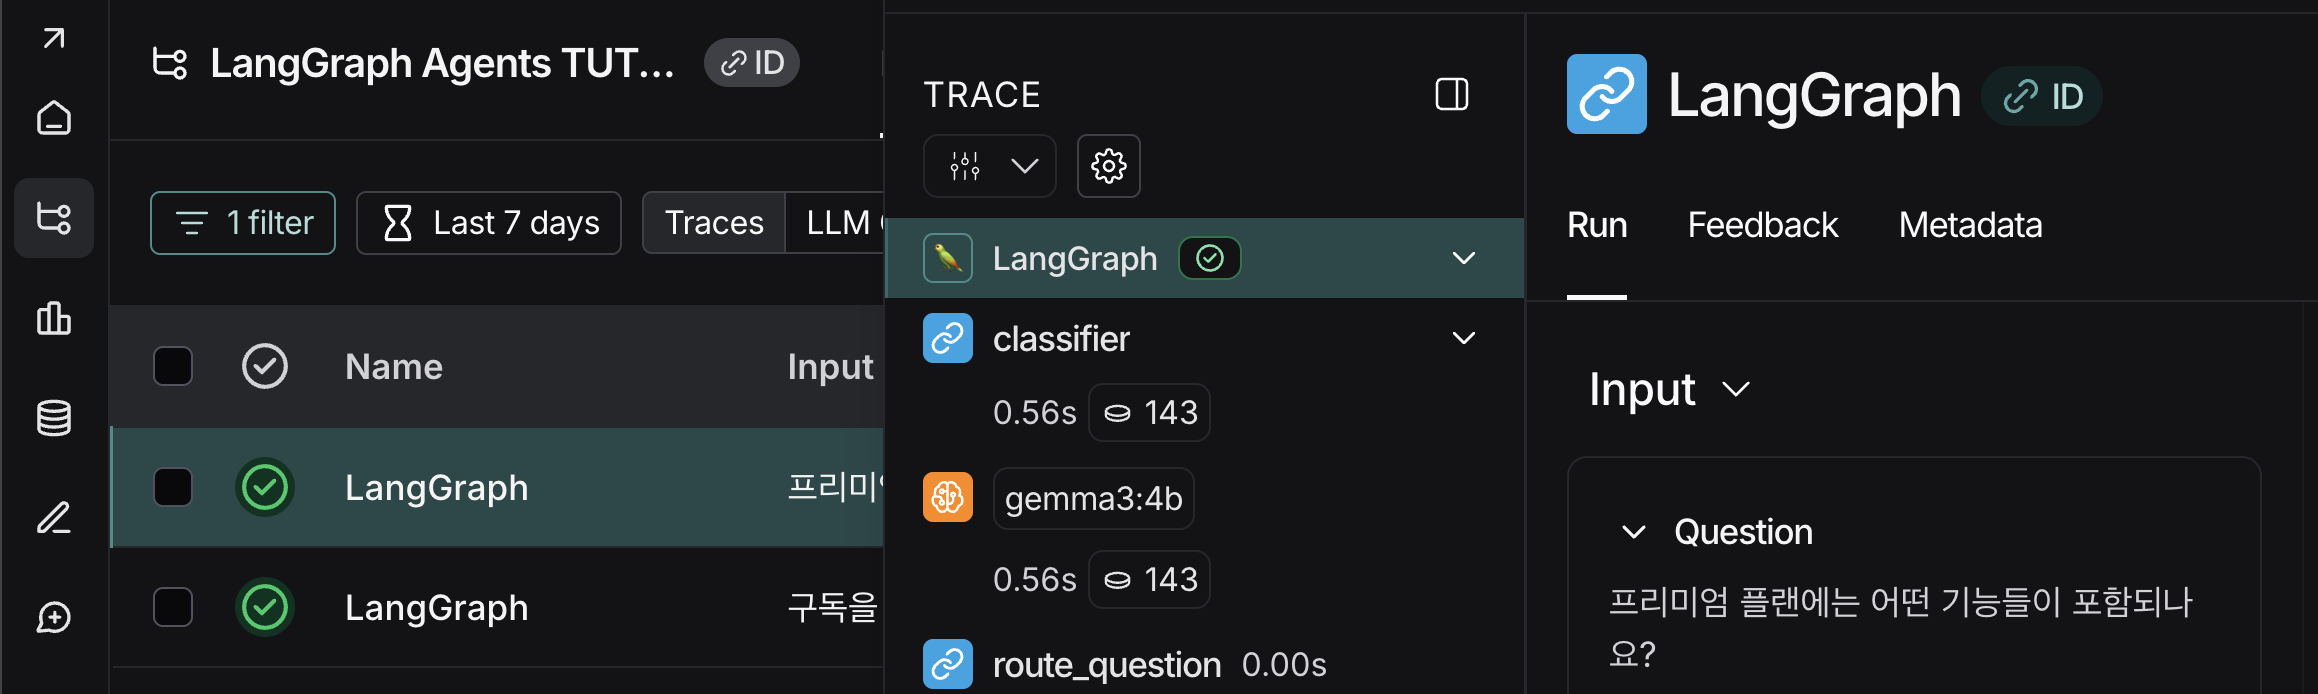